Basics

The reason why we are using RAG

1. LLM's are trained on large scale public data so they have not seen companies private data. With private data we can make them more tailored to a company/task. We can enrich their output.
2. Context sizes of these LLMs are increasing - this makes it easier for us to provide data to the LLM.

_RAG_

1. Documents can be indexed - for better retrieval using some huristics from the question.
2. Retriveval
3. Generation

_Concepts_

1. Query Translation

1.a we can break down a question into subquestion
1.b we can change the questions in some way that will be easier for us to search using it

2. Routing

2.a This is take a question - how do I get the correct datastore - sql, mongodb, vector store ...

3. Query Construction

3.a how do I convert a question into a query
3.b text to SQL, text to meta data filters in vector stores.


Indexing

_Available Methods_

1. Statistical

1.a here we can have a vector representing all the possible words that can be said. It contains the frequency of words said.

2. Embeddings

2.a ML to convert text to an embedding - a fixed sized vector representing a document.

2.b Embedding models have limited context. So documents have to be spilt up.

2.c Question can also be converted into a vector. We can do a comparison using some math operation.

Cosine Similarity

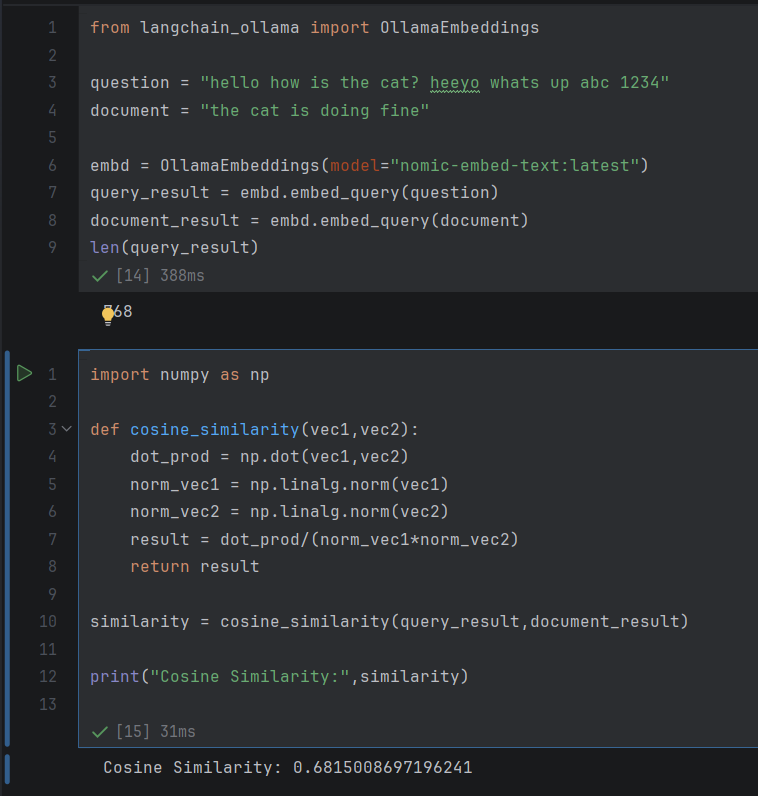

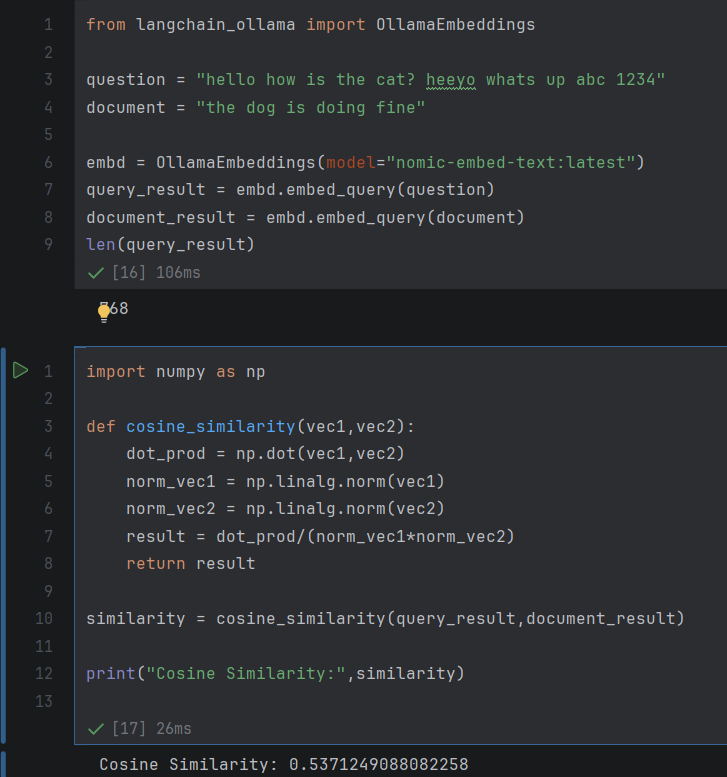

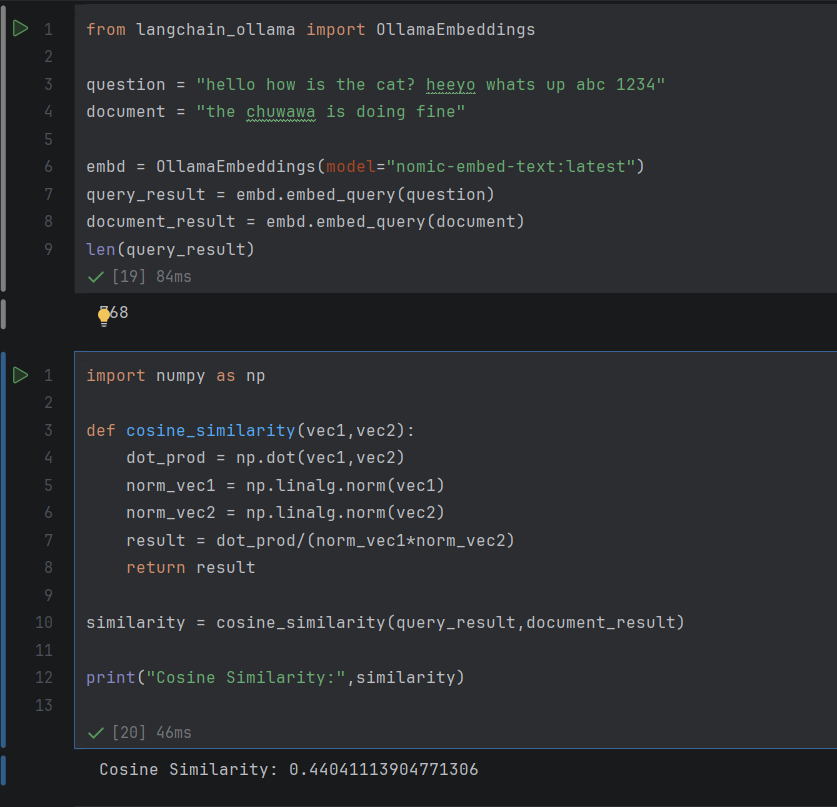

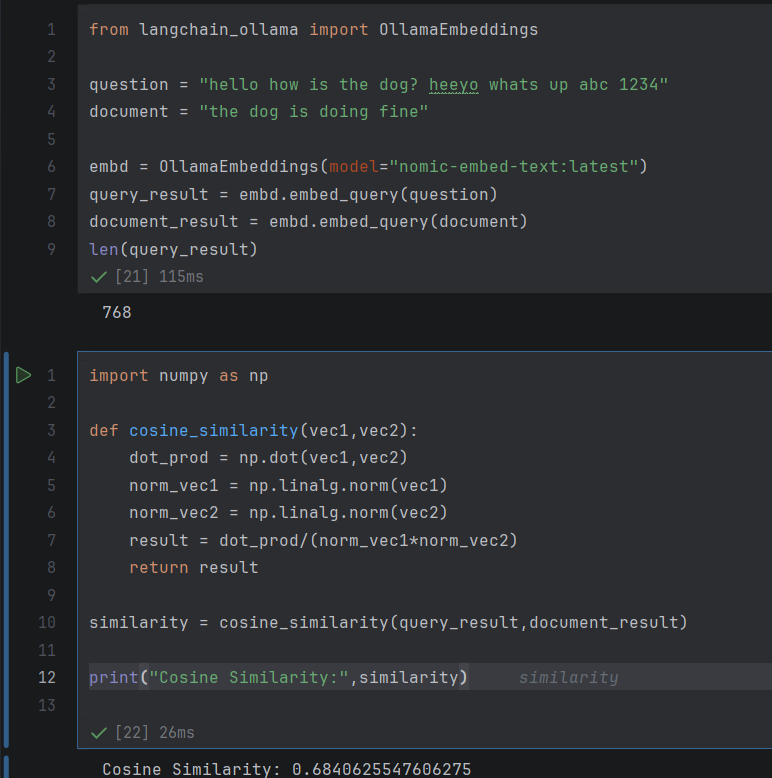

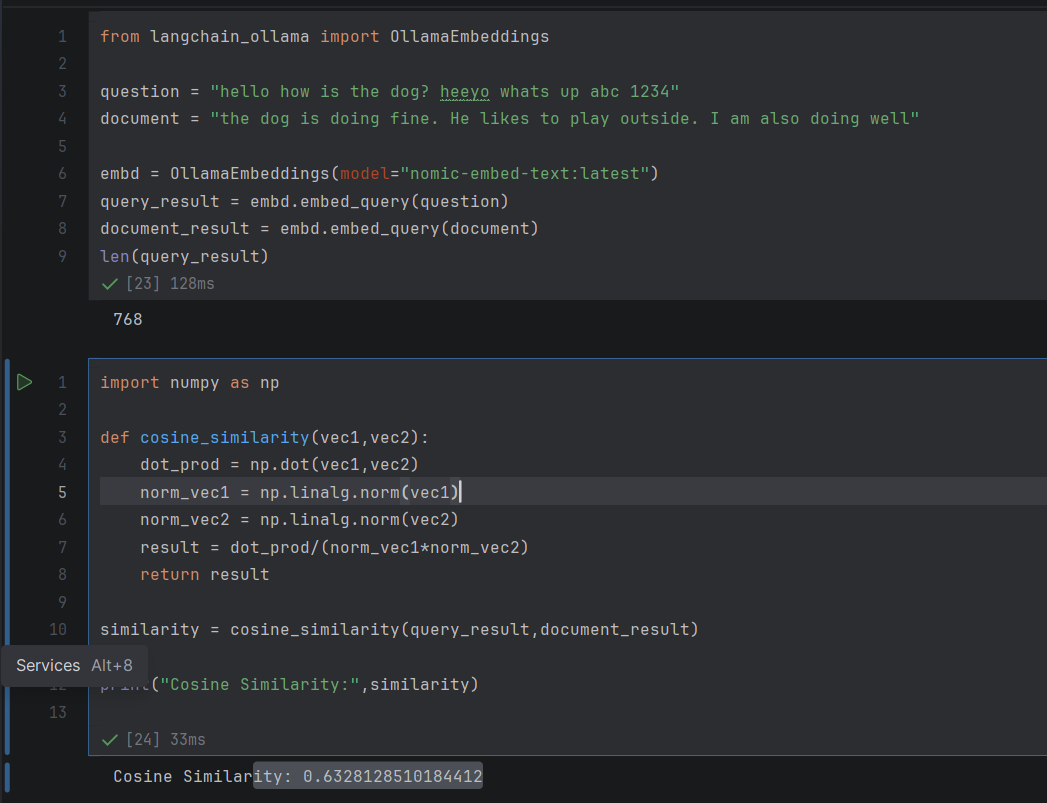

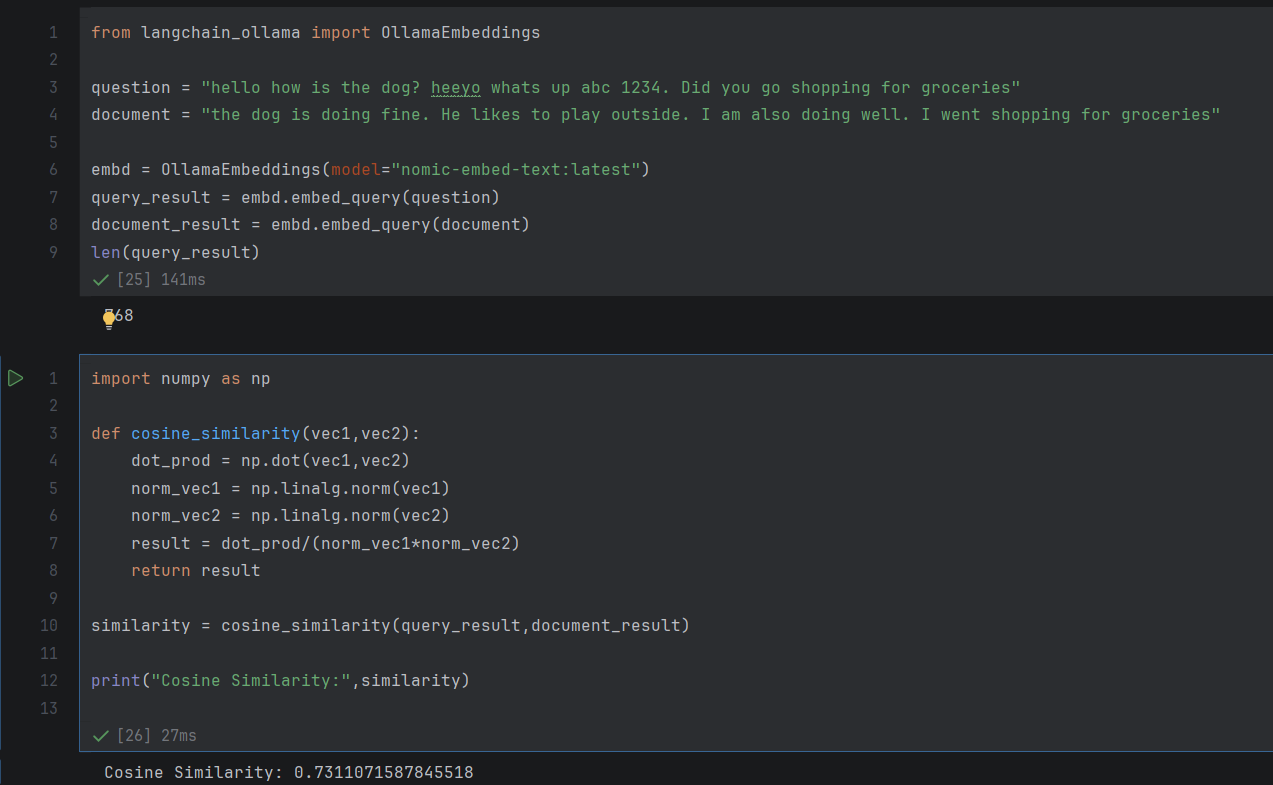



In [3]:
from idlelib import query

import tiktoken

question = "hello how is the cat? heeyo whats up abc 1234"
document = "the dog is doing fine"

def token_count(string: str,encoding_name : str)->int:
    encoding = tiktoken.get_encoding(encoding_name)
    print(encoding.encode(string))
    num_tokens = len(encoding.encode(string))
    return num_tokens

token_count(question,"o200k_base")

[24912, 1495, 382, 290, 9059, 30, 501, 58757, 55993, 869, 75094, 220, 7633, 19]


14

In [5]:
from langchain_ollama import OllamaEmbeddings

question = "hello how is the dog? heeyo whats up abc 1234. Did you go shopping for groceries"
document = "the dog is doing fine. He likes to play outside. I am also doing well. I went shopping for groceries"

embd = OllamaEmbeddings(model="nomic-embed-text:latest")
query_result = embd.embed_query(question)
document_result = embd.embed_query(document)
len(query_result)

768

In [6]:
import numpy as np

def cosine_similarity(vec1,vec2):
    dot_prod = np.dot(vec1,vec2)
    norm_vec1 = np.linalg.norm(vec1)
    norm_vec2 = np.linalg.norm(vec2)
    result = dot_prod/(norm_vec1*norm_vec2)
    return result

similarity = cosine_similarity(query_result,document_result)

print("Cosine Similarity:",similarity)


Cosine Similarity: 0.7311071587845518


In [7]:
# Curiosity
print(query_result)

[-0.052391827, 0.0072895293, -0.15417266, -0.05634552, 0.048878156, 0.00228306, -0.019385673, -0.00027369976, 0.009394176, -0.046700325, -0.01072917, 0.036443148, 0.048330456, 0.020032668, 0.011598928, -0.06011506, 0.013145805, -0.05244949, 0.039139874, 0.0025499086, 0.052467767, -0.0058085024, -0.02742974, -0.0065186783, 0.098865755, 0.028179355, 0.009380717, 0.11577756, -0.009930901, 0.059838116, -0.023558639, -0.04431211, 0.0047360286, -0.028512046, -0.025080351, 0.0070135933, 0.054530837, 0.054530658, -0.018666377, -0.0061046495, 0.053305946, 0.056199614, -0.027963031, 0.007669189, 0.02761031, 0.0076089334, 0.011329183, -0.017640777, 0.044771772, -0.060532756, -0.0123276925, 0.036323763, -0.023398254, -0.012123687, 0.0412591, -0.007247903, 0.07076836, 0.03460048, -0.03125666, 0.0042649433, 0.123443246, 0.01556914, -0.00023317382, 0.008831332, 0.05272262, -0.087504305, -0.013545811, 0.081370294, -0.041597173, -0.031160953, 0.05506155, -0.04654977, -0.0025068943, 0.021776147, -0.0236

In [8]:
import bs4
import requests
from langchain_core.documents import Document

url = "https://lilianweng.github.io/posts/2023-06-23-agent/"

resp = requests.get(url, headers={"User-Agent": "Mozilla/5.0"}, timeout=30)
resp.raise_for_status()

soup = bs4.BeautifulSoup(
    resp.text,
    "html.parser",
    parse_only=bs4.SoupStrainer(
        class_=("post-content", "post-title", "post-header")
    ),
)

blog_docs = [
    Document(
        page_content=soup.get_text(separator="\n", strip=True),
        metadata={"source": url},
    )
]

print(len(blog_docs[0].page_content))
print(blog_docs[0].page_content[:800])

43013
LLM Powered Autonomous Agents
Date: June 23, 2023  |  Estimated Reading Time: 31 min  |  Author: Lilian Weng
Building agents with LLM (large language model) as its core controller is a cool concept. Several proof-of-concepts demos, such as
AutoGPT
,
GPT-Engineer
and
BabyAGI
, serve as inspiring examples. The potentiality of LLM extends beyond generating well-written copies, stories, essays and programs; it can be framed as a powerful general problem solver.
Agent System Overview
#
In a LLM-powered autonomous agent system, LLM functions as the agent’s brain, complemented by several key components:
Planning
Subgoal and decomposition: The agent breaks down large tasks into smaller, manageable subgoals, enabling efficient handling of complex tasks.
Reflection and refinement: The agent can do s


In [9]:
from langchain_text_splitters import RecursiveCharacterTextSplitter

text_splitter = RecursiveCharacterTextSplitter.from_tiktoken_encoder(chunk_size=300,chunk_overlap = 50)

splits = text_splitter.split_documents(blog_docs)

In [13]:
print(len(splits))
count = 0
for split in splits:
    print(count,end="#####################\n\n")
    print(split.page_content,end="\n\n")
    print(split.metadata,end="\n\n")
    count+=1

44
0#####################

LLM Powered Autonomous Agents
Date: June 23, 2023  |  Estimated Reading Time: 31 min  |  Author: Lilian Weng
Building agents with LLM (large language model) as its core controller is a cool concept. Several proof-of-concepts demos, such as
AutoGPT
,
GPT-Engineer
and
BabyAGI
, serve as inspiring examples. The potentiality of LLM extends beyond generating well-written copies, stories, essays and programs; it can be framed as a powerful general problem solver.
Agent System Overview
#
In a LLM-powered autonomous agent system, LLM functions as the agent’s brain, complemented by several key components:
Planning
Subgoal and decomposition: The agent breaks down large tasks into smaller, manageable subgoals, enabling efficient handling of complex tasks.
Reflection and refinement: The agent can do self-criticism and self-reflection over past actions, learn from mistakes and refine them for future steps, thereby improving the quality of final results.
Memory
Short-term 

### **General Observation**

1. As per my reading this recursive function should be prefering keeping paragraphs intact.

paragraphs -> sentences -> words

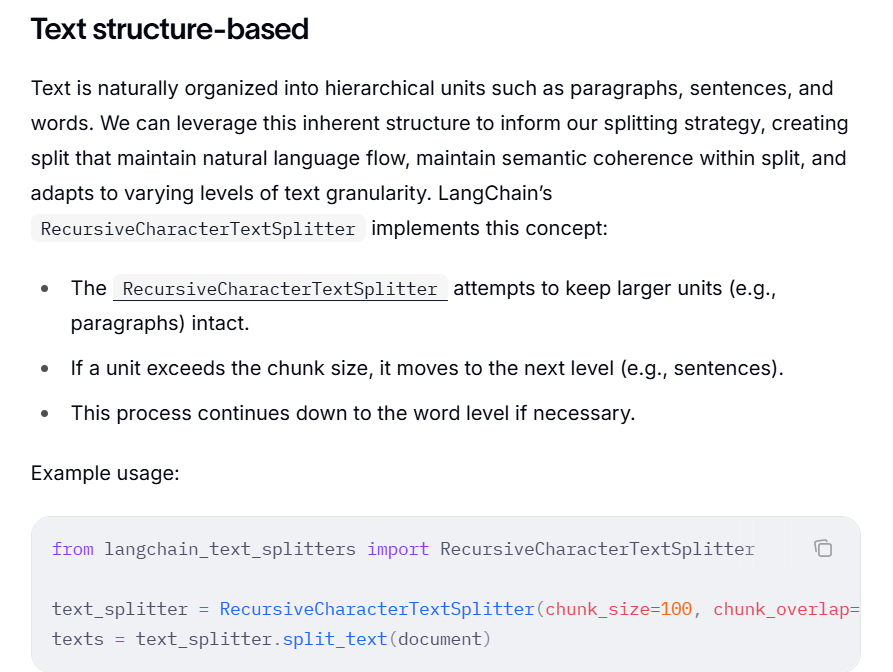

It tries to keep paragraphs intact. If the size is exceeded it tries to keep sentences intact.... down to words

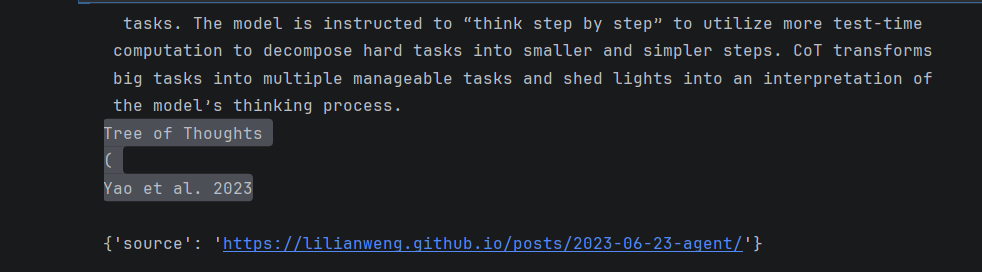

Sentence/paragraph broke down but not the word.

2. It stored a metadata link to where it got the information from.

{ source : url}

### Adding Data to Chroma

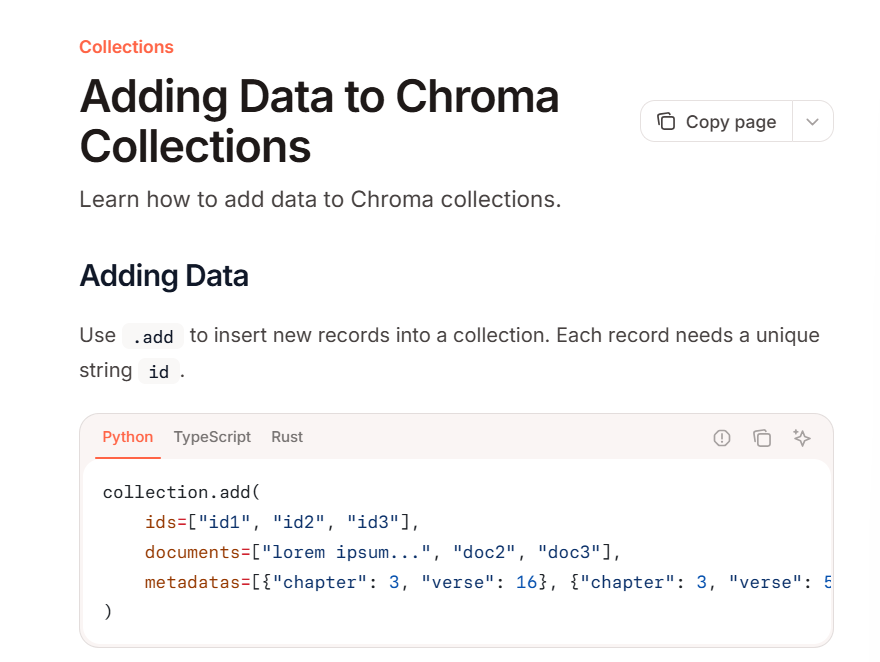


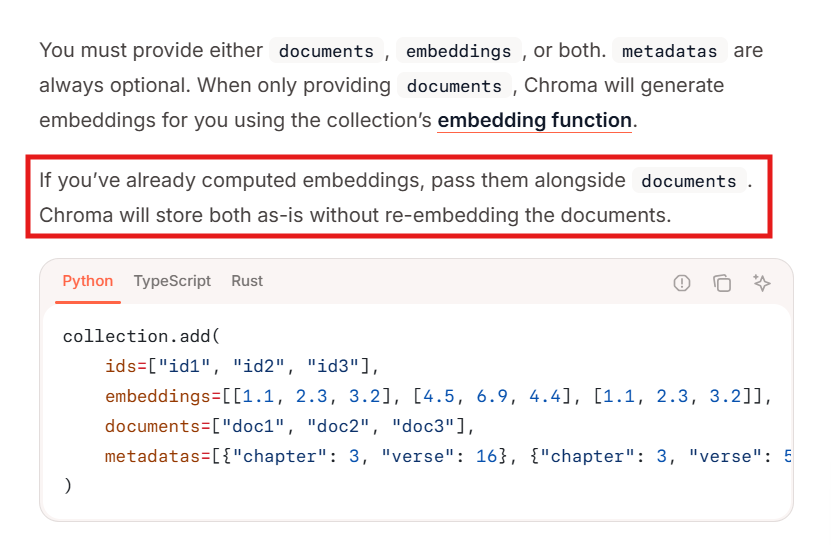
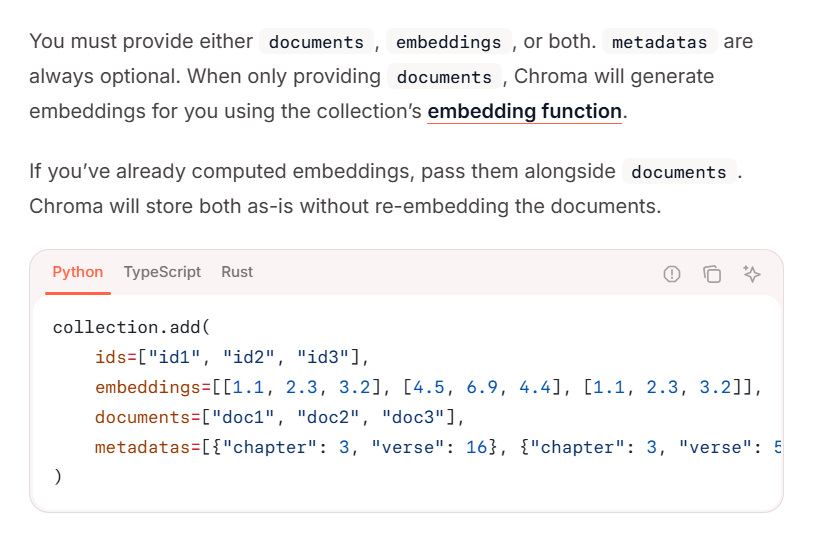


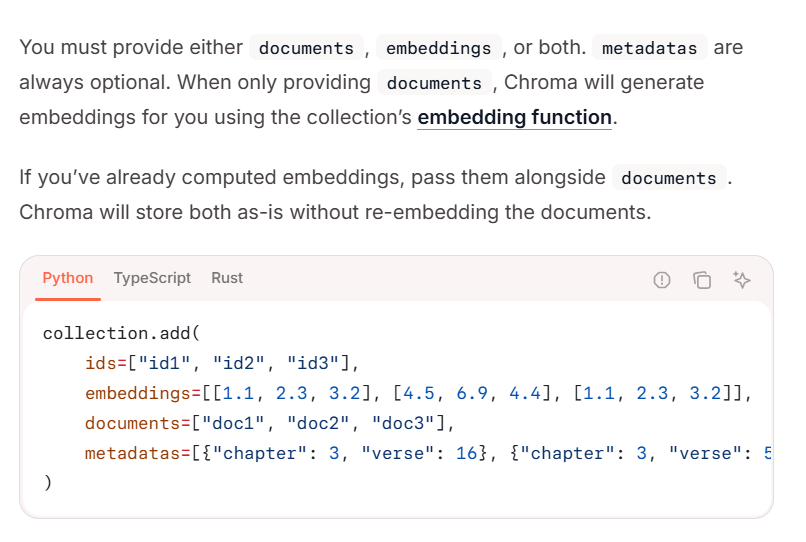

In [14]:
import chromadb
from chromadb.utils.embedding_functions.ollama_embedding_function import (
    OllamaEmbeddingFunction,
)

chroma_client = chromadb.Client()
collection = chroma_client.create_collection(name="my_collection")

documents = []
metadatas = []
ids = []
count = 0
for split in splits:
    documents.append(split.page_content)
    metadatas.append(split.metadata)
    ids.append("id"+str(count))
    count += 1

ollama_ef = OllamaEmbeddingFunction(
    url="http://localhost:11434",
    model_name="nomic-embed-text",
)

embeddings = ollama_ef(documents)

collection.add(ids=ids, embeddings=embeddings, metadatas=metadatas, documents=documents)




### Indexing

Done with Indexing

- we have split the document into chunks
- we have generated embedding using ollama
- stored it in chromadb (vectordb)
- we stored [ embedding, actual document, metadata (i.e source)]

Fun fact - we can even sort by metadata
